[Bank Marketing Data](https://archive.ics.uci.edu/ml/datasets/Bank+Marketing) dane z **Machine Learning Repository**

Dane związane z marketingową kampanią portugalskiej instytucji bankowej opartej na rozmowach telefonicznych. 


Input variables:
   # bank client data:
   1 - age (numeric)

   2 - job : type of job (categorical: "admin.","blue-collar""entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")
   
   3 - marital : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)
   
   4 - education (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")
   
   5 - default: has credit in default? (categorical: "no","yes","unknown")
   
   6 - housing: has housing loan? (categorical: "no","yes","unknown")
   
   7 - loan: has personal loan? (categorical: "no","yes","unknown")
   
   # related with the last contact of the current campaign:
   
   8 - contact: contact communication type (categorical: "cellular","telephone") 
   
   9 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  
  10 - day_of_week: last contact day of the week (categorical: "mon","tue","wed","thu","fri")
  
  11 - duration: last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
  
   # other attributes:
  
  12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  
  13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
  
  14 - previous: number of contacts performed before this campaign and for this client (numeric)
  
  15 - poutcome: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success")
  
   # social and economic context attributes
  
  16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
  
  17 - cons.price.idx: consumer price index - monthly indicator (numeric)     
  
  18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)     
  
  19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
  
  20 - nr.employed: number of employees - quarterly indicator (numeric)

  # Output variable (desired target):
  
  21 - y - has the client subscribed a term deposit? (binary: "yes","no")

In [120]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
sns.set() 

In [121]:
bank = pd.read_csv('bank-additional.csv', sep=';')
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [122]:
bank.columns.values

array(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'], dtype=object)

In [123]:
bank.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Metoda astype(int) konwertuje boolean (True/False) na integer (0/1).

In [124]:
bank['y']=(bank['y']=='yes').astype(int)

Zobaczmy jak to działa:

In [125]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,0
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,0
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,0


Wykształcenie

In [126]:
bank['education'].unique()

array(['basic.9y', 'high.school', 'university.degree',
       'professional.course', 'basic.6y', 'basic.4y', 'unknown',
       'illiterate'], dtype=object)

Połączmy 'basic.4y', 'basic.6y' oraz 'basic.9y' w kategorię 'Basic'

funkcja np.where(*condition*, X, Y) zwraca X jeśli *condition* jest prawdziwy, Y w przeciwnym przypadku



In [127]:
bank['education']=np.where(bank['education'] =='basic.9y', 'Basic', bank['education'])
bank['education']=np.where(bank['education'] =='basic.6y', 'Basic', bank['education'])
bank['education']=np.where(bank['education'] =='basic.4y', 'Basic', bank['education'])
bank['education']=np.where(bank['education'] =='university.degree', 'University Degree', bank['education'])
bank['education']=np.where(bank['education'] =='professional.course', 'Professional Course', bank['education'])
bank['education']=np.where(bank['education'] =='high.school', 'High School', bank['education'])
bank['education']=np.where(bank['education'] =='illiterate', 'Illiterate', bank['education'])
bank['education']=np.where(bank['education'] =='unknown', 'Unknown', bank['education'])

inny sposób zrobienia tego samego - w padas to samo można zrobić na wiele sposobów

In [128]:
bank['education'] = bank['education'].map({'basic.9y':'Basic', 'basic.6y':'Basic', 'basic.4y':'Basic', 
                                           'university.degree':'University Degree', 'professional.course':'Professional Course',
                                           'high.school':'High School', 'illiterate':'Illiterate', 'unknown':'Unknown'})

In [129]:
bank['education'].unique()

array([nan], dtype=object)

In [130]:
bank['education'].value_counts()

Series([], Name: count, dtype: int64)

wyrzucamy jedną osobę, która jest Illiterate (analfabeta?)

In [131]:
bank = bank.drop(bank[bank['education']=='Illiterate'].index)

In [132]:
bank['education'].value_counts()

Series([], Name: count, dtype: int64)

### Eksploracja danych

Sprawdźmy ile osób zamówiło lokatę

In [133]:
bank['y'].value_counts()

y
0    3668
1     451
Name: count, dtype: int64

Porównajmy zmienne ilościowe z podziałem na klietów, którzy zamówili lokatę i tych, którzy nie zamówili


In [134]:
numerical_col = ['duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed','y']
bank[numerical_col].groupby(by ='y').mean()

,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
y,,,,,,,,,
0,219.40976,2.605780,982.763086,0.141767,0.240185,93.599677,-40.586723,3.802826,5175.502072
1,560.78714,1.980044,778.722838,0.585366,-1.177384,93.417268,-39.786475,2.145448,5093.118625


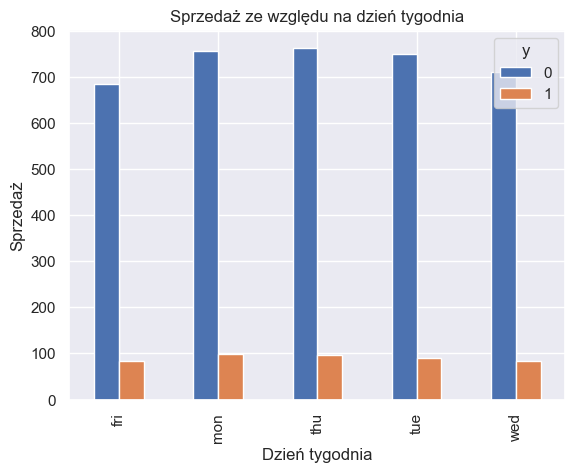

In [135]:
%matplotlib inline
import matplotlib.pyplot as plt
pd.crosstab(bank.day_of_week,bank.y).plot(kind='bar')
plt.title('Sprzedaż ze względu na dzień tygodnia')
plt.xlabel('Dzień tygodnia')
plt.ylabel('Sprzedaż')
plt.show()

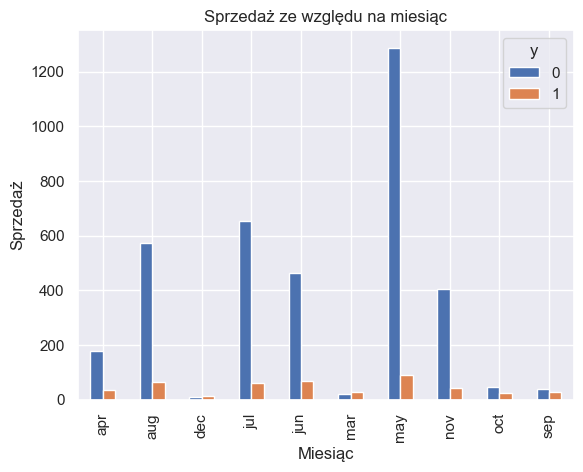

In [136]:
%matplotlib inline
import matplotlib.pyplot as plt
pd.crosstab(bank['month'],bank.y).plot(kind='bar')
plt.title('Sprzedaż ze względu na miesiąc')
plt.xlabel('Miesiąc')
plt.ylabel('Sprzedaż')
plt.show()

Text(0, 0.5, 'Sprzedaż')

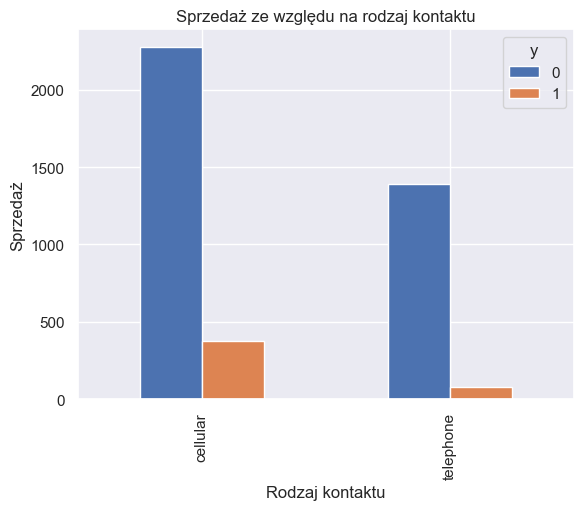

In [137]:
%matplotlib inline
import matplotlib.pyplot as plt
pd.crosstab(bank['contact'],bank.y).plot(kind='bar')
plt.title('Sprzedaż ze względu na rodzaj kontaktu')
plt.xlabel('Rodzaj kontaktu')
plt.ylabel('Sprzedaż')

Text(0, 0.5, 'Sprzedaż')

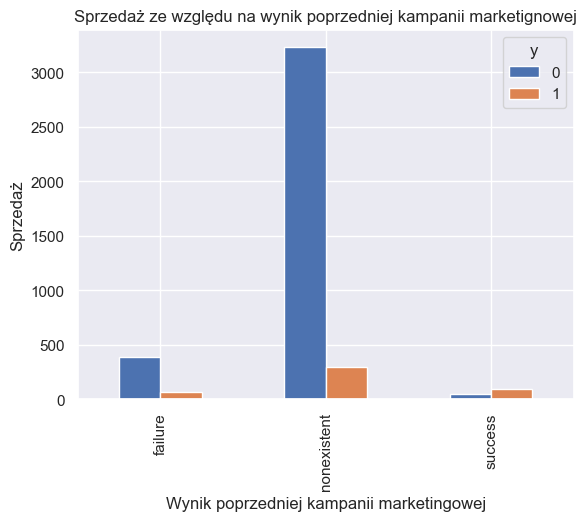

In [138]:
%matplotlib inline
import matplotlib.pyplot as plt
pd.crosstab(bank['poutcome'],bank.y).plot(kind='bar')
plt.title('Sprzedaż ze względu na wynik poprzedniej kampanii marketignowej')
plt.xlabel('Wynik poprzedniej kampanii marketingowej')
plt.ylabel('Sprzedaż')

### Zmienne binarne

In [139]:
categorical_variables=['job','marital','education','default','housing','loan','contact','month','day_of_week','poutcome']
bank_final = pd.get_dummies(bank, columns=categorical_variables, drop_first=True)

In [140]:
bank_final.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,True,False,False,False,False,False,False,False,True,False
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,True,False,False,False,False,False,False,False,True,False
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,False,False,False,False,False,False,False,True,True,False
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,False,False,False,False,False,False,False,False,True,False
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,False,True,False,False,True,False,False,False,True,False


In [141]:
bank_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   4119 non-null   int64  
 1   duration              4119 non-null   int64  
 2   campaign              4119 non-null   int64  
 3   pdays                 4119 non-null   int64  
 4   previous              4119 non-null   int64  
 5   emp.var.rate          4119 non-null   float64
 6   cons.price.idx        4119 non-null   float64
 7   cons.conf.idx         4119 non-null   float64
 8   euribor3m             4119 non-null   float64
 9   nr.employed           4119 non-null   float64
 10  y                     4119 non-null   int32  
 11  job_blue-collar       4119 non-null   bool   
 12  job_entrepreneur      4119 non-null   bool   
 13  job_housemaid         4119 non-null   bool   
 14  job_management        4119 non-null   bool   
 15  job_retired          

In [142]:
X = bank_final.drop(columns='y') 
y = bank_final['y']  

In [143]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [144]:
reg_log = LogisticRegression(max_iter=100)
results_log = reg_log.fit(X_train,y_train)

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Skoro mamy 50 zmiennych, więc także 50 parametrów $\beta_1,\dots,\beta_{50}$

In [145]:
results_log.coef_

array([[ 3.65985567e-03,  5.29072337e-03, -8.69097934e-02,
        -1.51175299e-03,  3.61638695e-02, -2.67346332e-01,
         2.44568896e-01,  5.89696169e-02, -3.03508533e-01,
        -4.33012324e-03, -1.70737716e-02, -5.21023116e-03,
         7.17727405e-04, -5.58771269e-03,  1.26398053e-03,
        -4.85013917e-03,  2.01396457e-03,  7.41836780e-03,
         7.20221573e-03,  5.15723299e-03, -3.10359827e-04,
        -1.66466915e-02,  2.53334702e-02, -7.52776991e-05,
        -1.86552302e-02, -2.84642488e-05, -1.36789608e-03,
         5.36351146e-03, -1.36789608e-03, -1.45960247e-03,
        -4.32821514e-02,  5.24654640e-03,  4.78506876e-03,
        -8.02604203e-03,  1.09547276e-02,  1.47830912e-02,
        -3.74596081e-02, -9.56469970e-03,  1.08815790e-02,
         6.29970130e-03,  8.87617643e-03,  2.25368399e-03,
        -2.85914327e-03,  5.26840894e-04, -1.30764592e-02,
         4.87410621e-03]])

In [146]:
d = {'Zmienne': X.columns, 'Współczynniki beta': results_log.coef_[0]}
coef_df = pd.DataFrame(data=d)
coef_df

,Zmienne,Współczynniki beta
0,age,0.003660
1,duration,0.005291
2,campaign,-0.086910
3,pdays,-0.001512
4,previous,0.036164
5,emp.var.rate,-0.267346
6,cons.price.idx,0.244569
7,cons.conf.idx,0.058970
8,euribor3m,-0.303509
9,nr.employed,-0.004330


In [147]:
y_test_pred = reg_log.predict(X_test)
y_train_pred = reg_log.predict(X_train)

In [148]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
confusion_matrix(y_test,y_test_pred)

array([[718,  30],
       [ 43,  33]], dtype=int64)

In [149]:
accuracy_score(y_test,y_test_pred)

0.9114077669902912

$\text{Confusion Matrix} =\begin{bmatrix}
\text{True Negative} & \text{False Positive} \\
\text{False Negative} & \text{True Positive} 
\end{bmatrix}$

$\text{accuracy}=\frac{TN+TP}{TN+FN+FP+TP}=\frac{\text{well-predicted observations}}{\text{all observations}}$

$\text{precision}=\frac{TP}{FP+TP}=\frac{\text{well-predicted positive}}{\text{all observations predicted as positive}}$

$\text{recall}=\frac{TP}{FN+TP}=\frac{\text{well-predicted positve}}{\text{all observations which are positive}}$

In [150]:
precision_score(y_test,y_test_pred)

0.5238095238095238

In [151]:
recall_score(y_test,y_test_pred)

0.4342105263157895

### Feature selection - wybór zmiennych

https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html

In [152]:
from sklearn import datasets
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=100)

rfe = RFE(model, n_features_to_select=12)
rfe = rfe.fit(X_train,y_train)
print(rfe.support_)
print(rfe.ranking_)

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\HP\anaconda3\envs\wad\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regressi

[False False False False  True False False False  True False False False
 False  True False  True False False False False False False False False
 False False False False False False False False  True  True  True  True
  True False  True False False False False False  True  True]
[30 28 14 33  1 11 19 16  1 23  6  4 25  1 22  1  5 20 17 15 32 24 21 34
 13 35 10 12  7 31  3  8  1  1  1  1  1 18  1  2 27 26 29  9  1  1]


In [153]:
selected_columns=[]
for i in range(len(X.columns)):
    if rfe.support_[i]:
        selected_columns.append(X.columns[i])
print(selected_columns)

['previous', 'euribor3m', 'job_management', 'job_self-employed', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_oct', 'poutcome_nonexistent', 'poutcome_success']


In [154]:
X1=X[selected_columns]
y = bank_final['y'] 

In [155]:
X1.columns

Index(['previous', 'euribor3m', 'job_management', 'job_self-employed',
       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_oct', 'poutcome_nonexistent', 'poutcome_success'],
      dtype='object')

In [156]:
y_test_pred = rfe.predict(X_test)
y_train_pred = rfe.predict(X_train)
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
confusion_matrix(y_test,y_test_pred)

array([[737,  11],
       [ 64,  12]], dtype=int64)